In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings('ignore')

### Load data and initial setup

In [2]:
df = pd.read_csv(r"C:\Users\Asus\Documents\Projects\house-price-prediction\notebook\data\house_price.csv")

In [3]:
print("Data shape:", df.shape)

Data shape: (545, 13)


In [4]:
print("\nColumn names and data types:")
print(df.dtypes)


Column names and data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### Data Cleaning

In [6]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")


Duplicate rows: 0


In [8]:
# Check for inconsistent categories (e.g., unexpected values in categorical columns)
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for col in cat_cols:
    print(f"{col} unique values: {df[col].unique()}")

mainroad unique values: <StringArray>
['yes', 'no']
Length: 2, dtype: str
guestroom unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str
basement unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str
hotwaterheating unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str
airconditioning unique values: <StringArray>
['yes', 'no']
Length: 2, dtype: str
prefarea unique values: <StringArray>
['yes', 'no']
Length: 2, dtype: str
furnishingstatus unique values: <StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


###  EXPLORING DATA

In [9]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 13 numerical features : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

We have 0 categorical features : []


In [10]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

### Univariate Analysis

In [11]:
# Numerical variables
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [12]:
# Summary statistics
print("\nDescriptive statistics for numerical features:")
print(df[num_cols].describe())


Descriptive statistics for numerical features:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [13]:
# Skewness and kurtosis
for col in num_cols:
    print(f"{col}: skewness = {skew(df[col]):.3f}, kurtosis = {kurtosis(df[col]):.3f}")

price: skewness = 1.209, kurtosis = 1.931
area: skewness = 1.318, kurtosis = 2.715
bedrooms: skewness = 0.494, kurtosis = 0.711
bathrooms: skewness = 1.585, kurtosis = 2.134
stories: skewness = 1.079, kurtosis = 0.662
parking: skewness = 0.840, kurtosis = -0.579


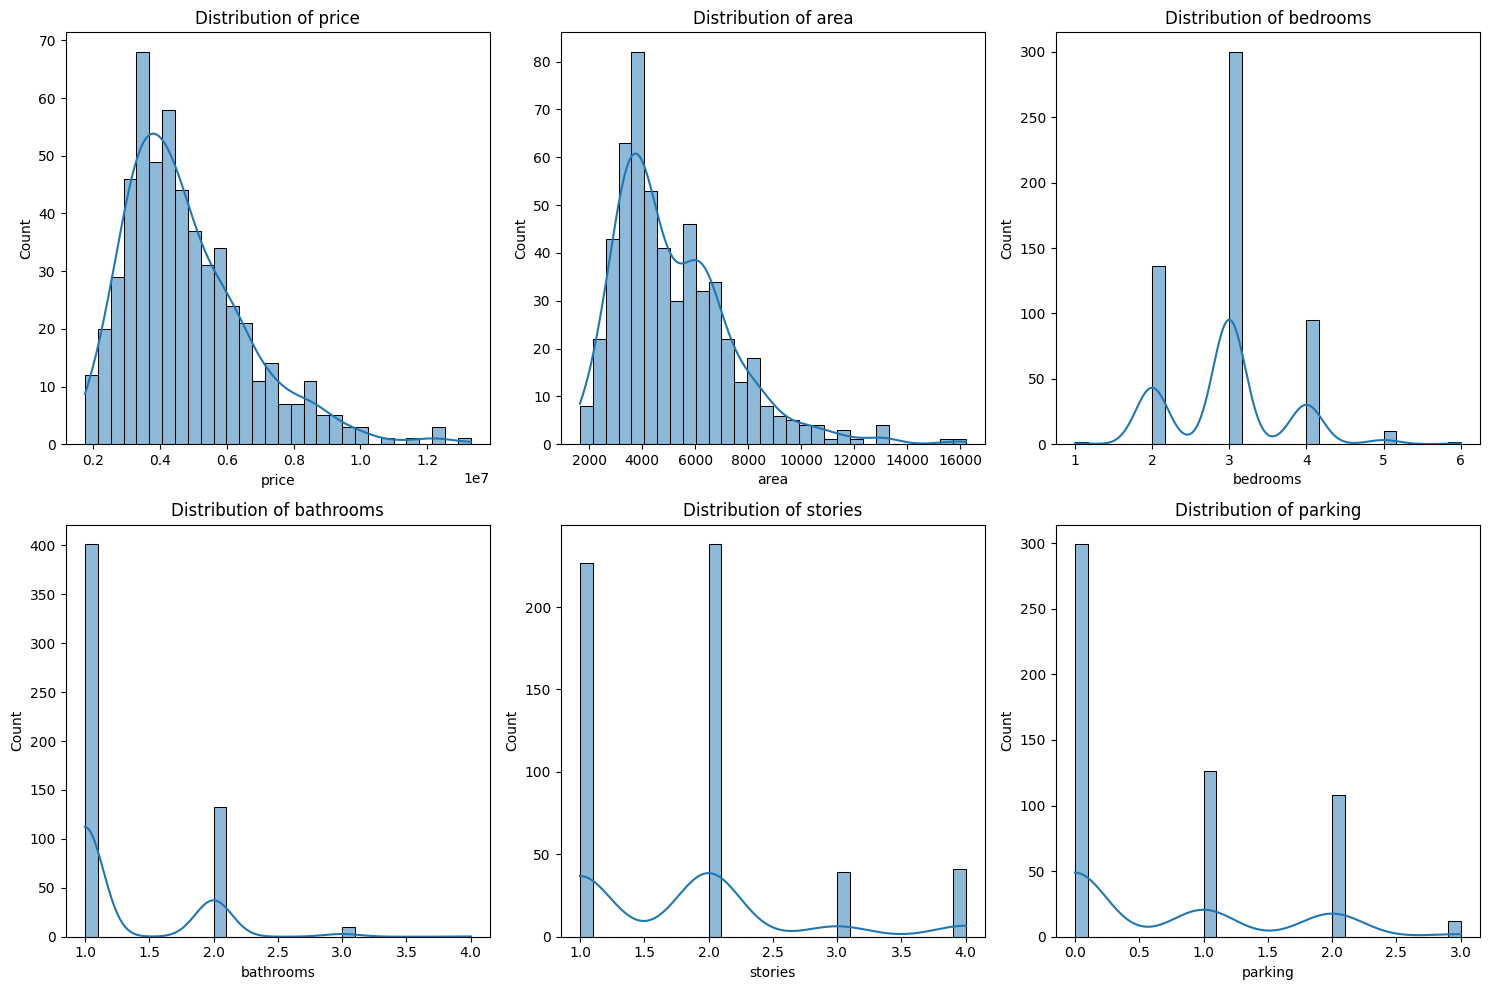

In [14]:
# Histograms with KDE
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Interpretations:**

price: Right‑skewed (skew=1.52), high kurtosis (2.86). Most prices lie between 2–6M, with a long tail up to 13.3M. Suggests a log transformation may help.

area: Also right‑skewed (skew=1.64) with a long tail. Most houses have area 3000–6000 sqft.

bedrooms: Discrete, mostly 3 (mean 3.1) and 4. Few 1,2,5,6.

bathrooms: Discrete, concentrated at 1 and 2 (mean 1.4). Few 3 and 4.

stories: Discrete, mostly 1,2,4. Few 3‑story houses.

parking: Highly right‑skewed, most houses have 0 or 1 parking sp

### Categorical Features

In [15]:
# Categorical variables
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

In [16]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True))


mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64
mainroad
yes    0.858716
no     0.141284
Name: proportion, dtype: float64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64
guestroom
no     0.822018
yes    0.177982
Name: proportion, dtype: float64

basement:
basement
no     354
yes    191
Name: count, dtype: int64
basement
no     0.649541
yes    0.350459
Name: proportion, dtype: float64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
hotwaterheating
no     0.954128
yes    0.045872
Name: proportion, dtype: float64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64
airconditioning
no     0.684404
yes    0.315596
Name: proportion, dtype: float64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64
prefarea
no     0.765138
yes    0.234862
Name: proportion, dtype: float64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
N

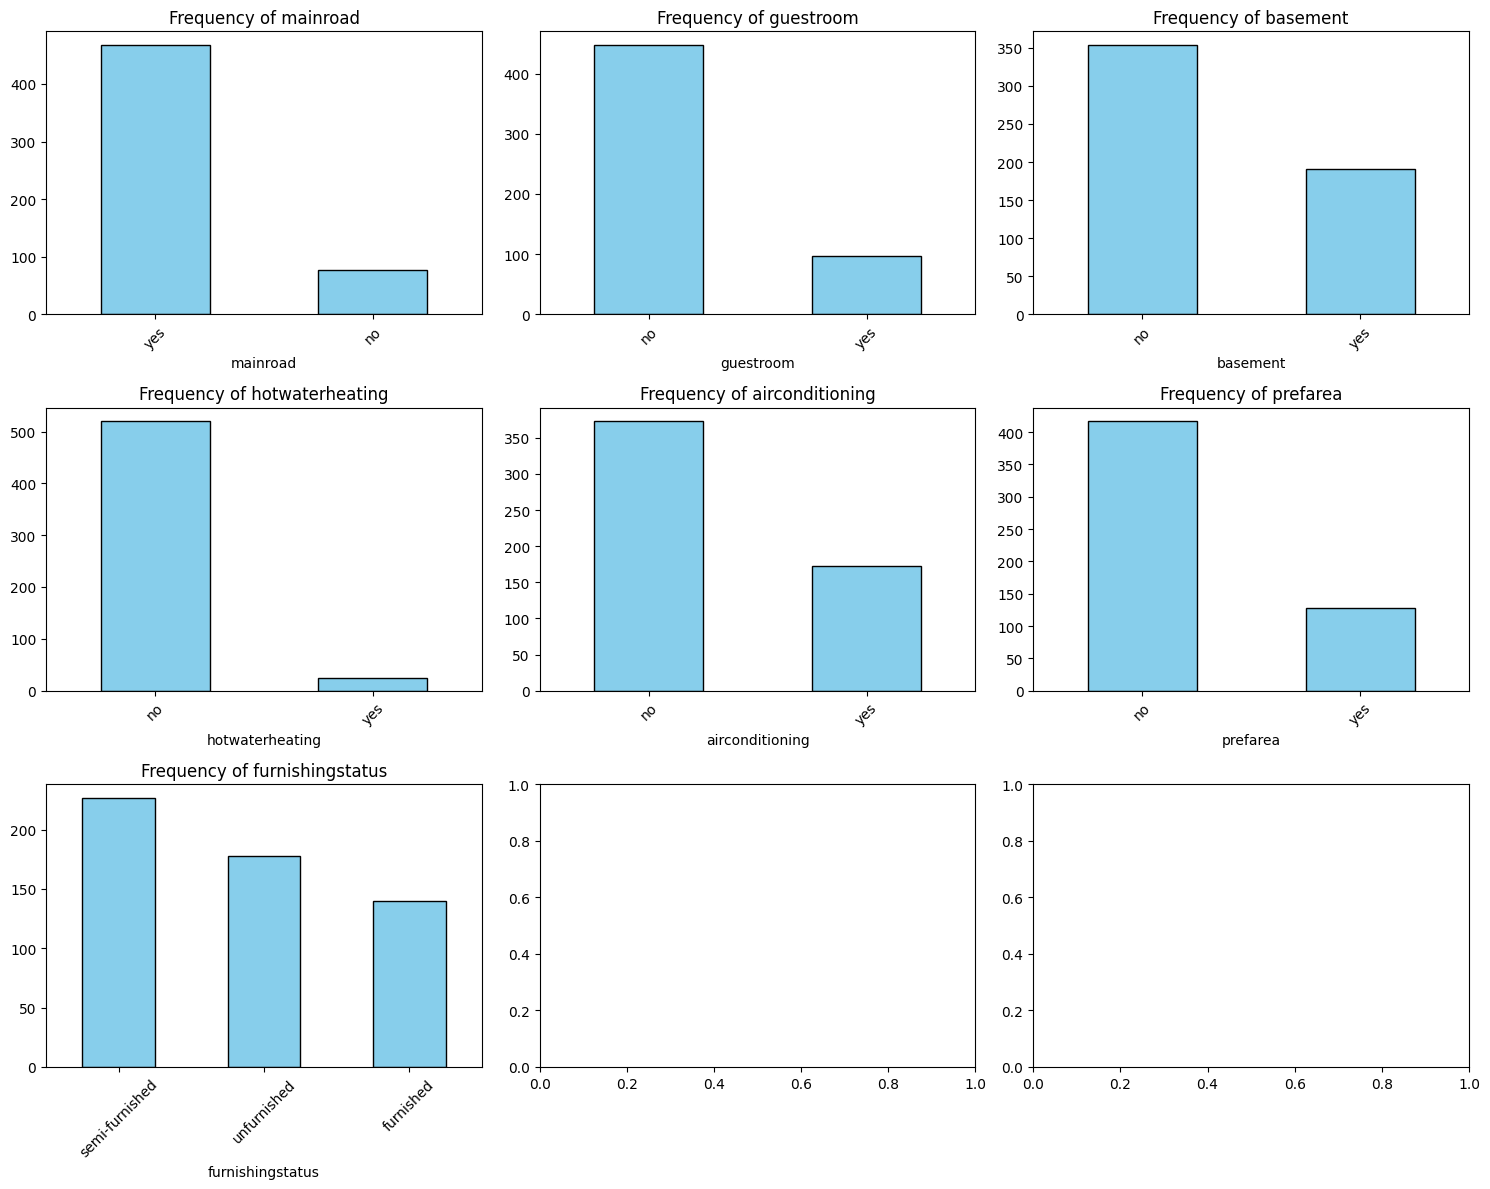

In [17]:
# Bar charts
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Frequency of {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Bivariate Analysis

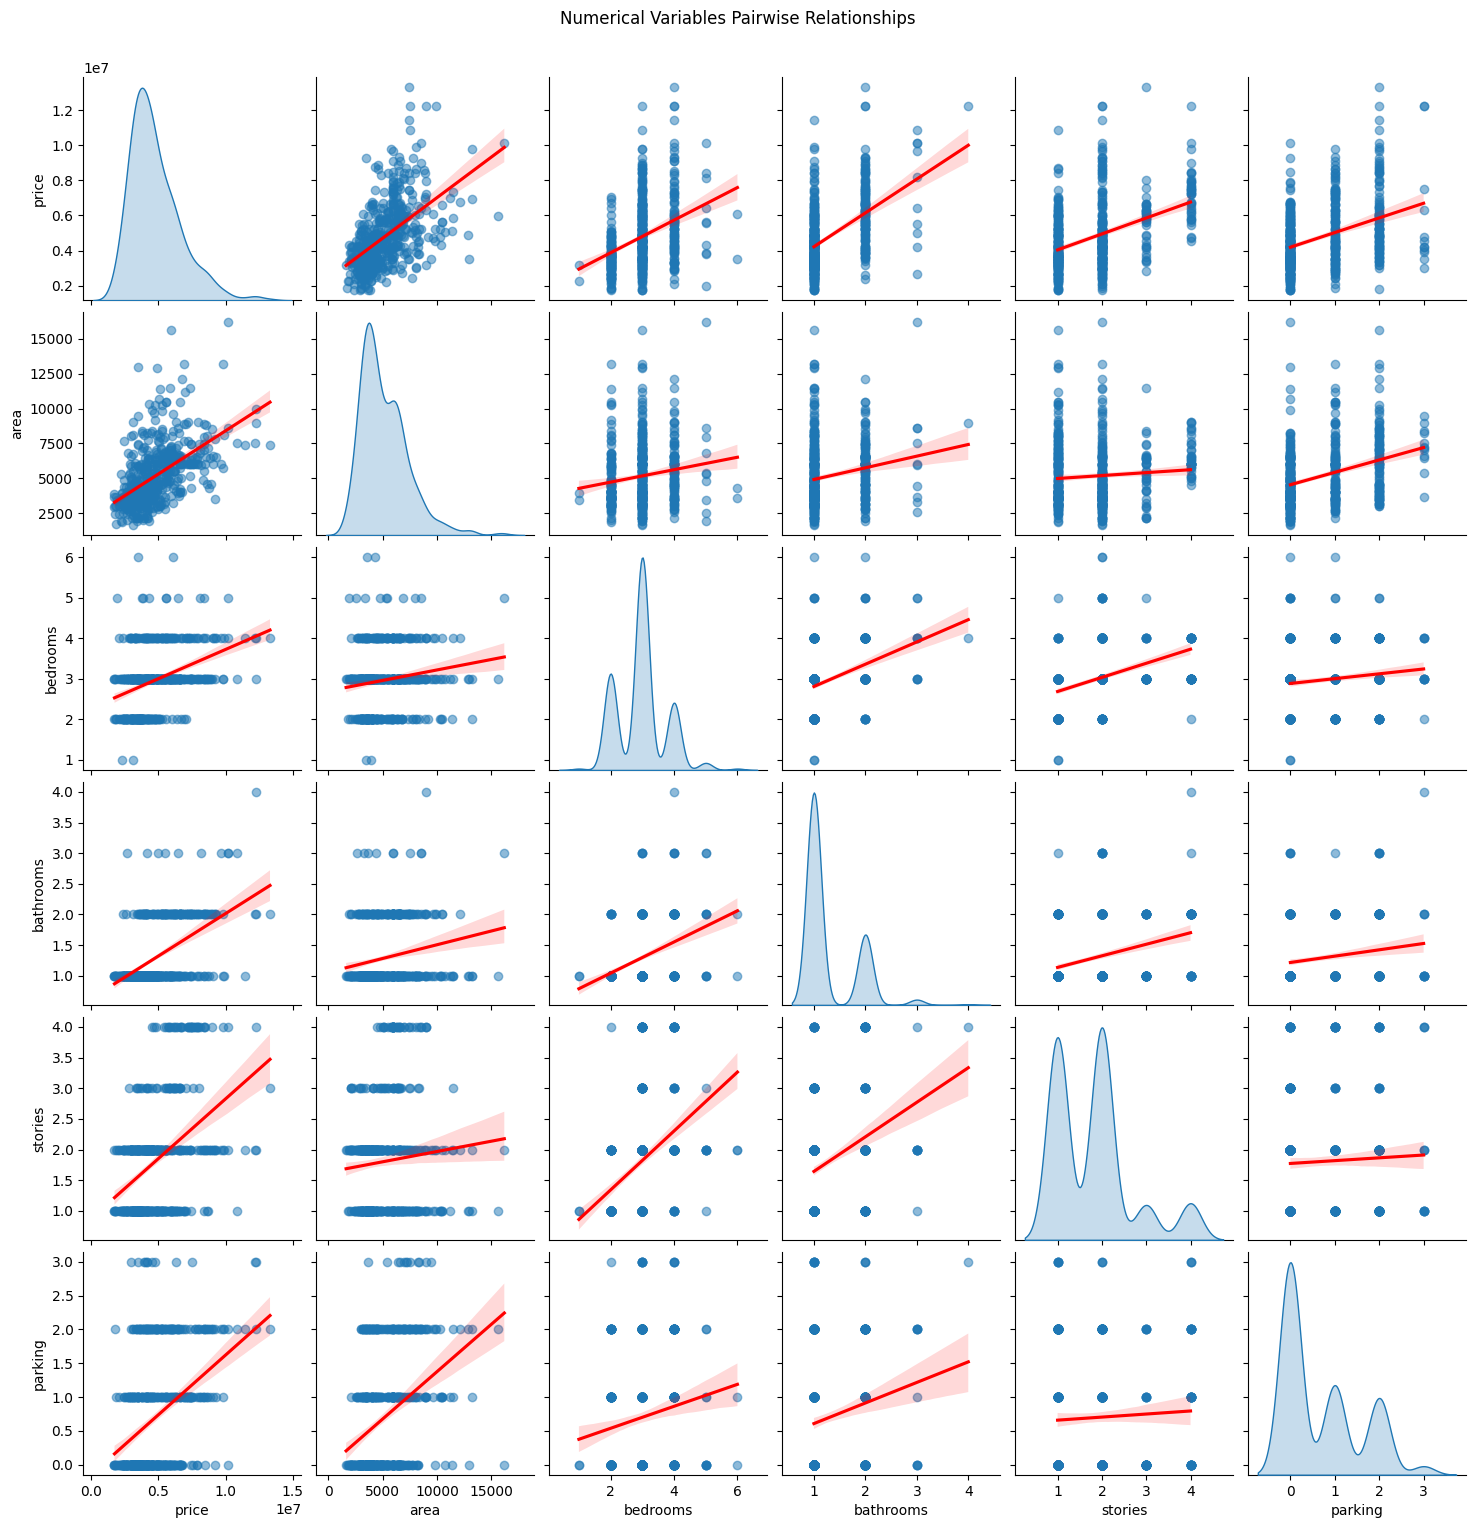

In [18]:
# Scatter plots with regression lines
sns.pairplot(df[num_cols], diag_kind='kde', kind='reg',
             plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws': {'alpha': 0.5}})
plt.suptitle('Numerical Variables Pairwise Relationships', y=1.02)
plt.show()

In [19]:
# Pearson and Spearman correlations
pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')
print("Pearson correlation with price:")
print(pearson_corr['price'].sort_values(ascending=False))
print("\nSpearman correlation with price:")
print(spearman_corr['price'].sort_values(ascending=False))

Pearson correlation with price:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

Spearman correlation with price:
price        1.000000
area         0.602859
bathrooms    0.479912
bedrooms     0.390454
parking      0.365372
stories      0.362856
Name: price, dtype: float64


### Categorical vs Target (price)

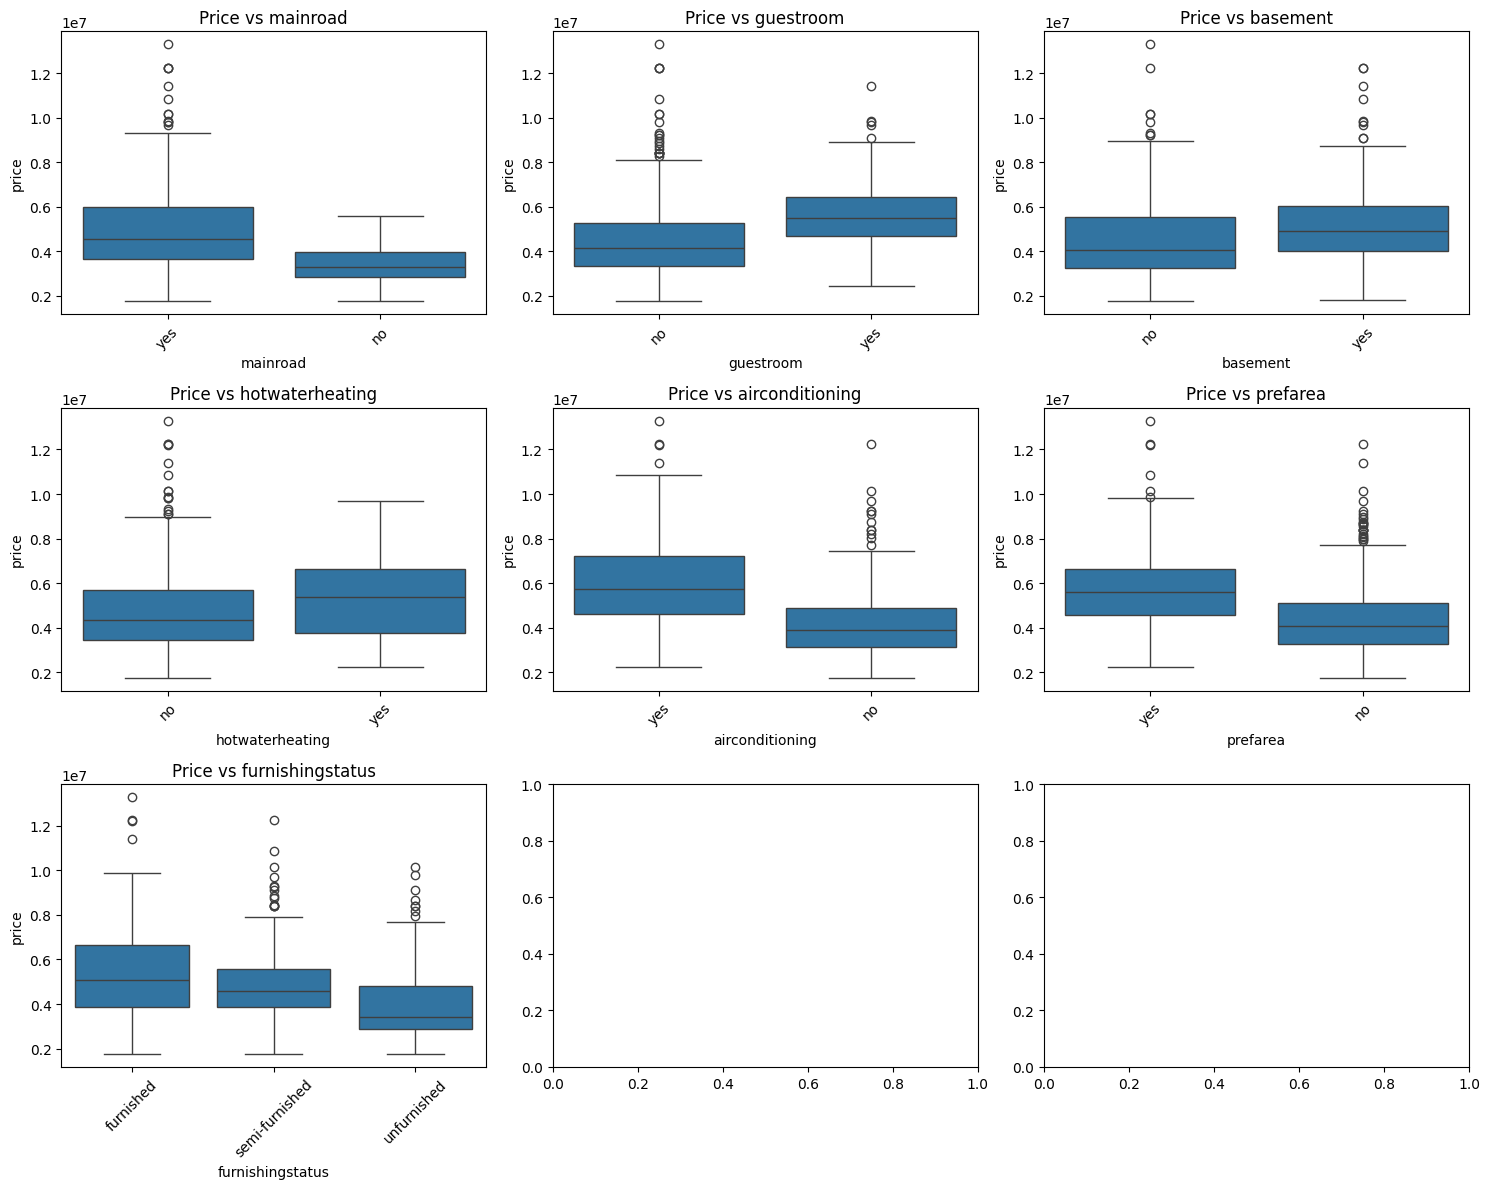

In [20]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['price'], ax=axes[i])
    axes[i].set_title(f'Price vs {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Statistical tests
for col in cat_cols:
    groups = [df[df[col] == cat]['price'] for cat in df[col].unique()]
    if len(groups) == 2:
        stat, p = ttest_ind(*groups)
        test = "t-test"
    else:
        stat, p = f_oneway(*groups)
        test = "ANOVA"
    print(f"{col} ({test}): p-value = {p:.5f}")

mainroad (t-test): p-value = 0.00000
guestroom (t-test): p-value = 0.00000
basement (t-test): p-value = 0.00001
hotwaterheating (t-test): p-value = 0.02982
airconditioning (t-test): p-value = 0.00000
prefarea (t-test): p-value = 0.00000
furnishingstatus (ANOVA): p-value = 0.00000


### Categorical vs Categorical

In [22]:
# Chi-square tests
chi_results = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1, col2 = cat_cols[i], cat_cols[j]
        contingency = pd.crosstab(df[col1], df[col2])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({'Feature1': col1, 'Feature2': col2, 'Chi2': chi2, 'p-value': p})
chi_df = pd.DataFrame(chi_results)
print(chi_df.sort_values('p-value').to_string(index=False))

       Feature1         Feature2      Chi2      p-value
      guestroom         basement 73.420923 1.047498e-17
       basement         prefarea 27.235386 1.801315e-07
       mainroad         prefarea 20.440301 6.152055e-06
      guestroom         prefarea 13.134012 2.899832e-04
airconditioning furnishingstatus 14.645289 6.604135e-04
       mainroad furnishingstatus 13.387092 1.238882e-03
      guestroom  airconditioning  9.643100 1.900642e-03
hotwaterheating  airconditioning  7.924979 4.875691e-03
airconditioning         prefarea  6.925328 8.498342e-03
       basement furnishingstatus  7.884672 1.940284e-02
       mainroad  airconditioning  5.423399 1.986865e-02
      guestroom furnishingstatus  7.636898 2.196184e-02
       prefarea furnishingstatus  6.536538 3.807226e-02
       mainroad        guestroom  3.979504 4.605712e-02
hotwaterheating         prefarea  1.312104 2.520141e-01
hotwaterheating furnishingstatus  2.610151 2.711520e-01
       basement  airconditioning  1.017278 3.131

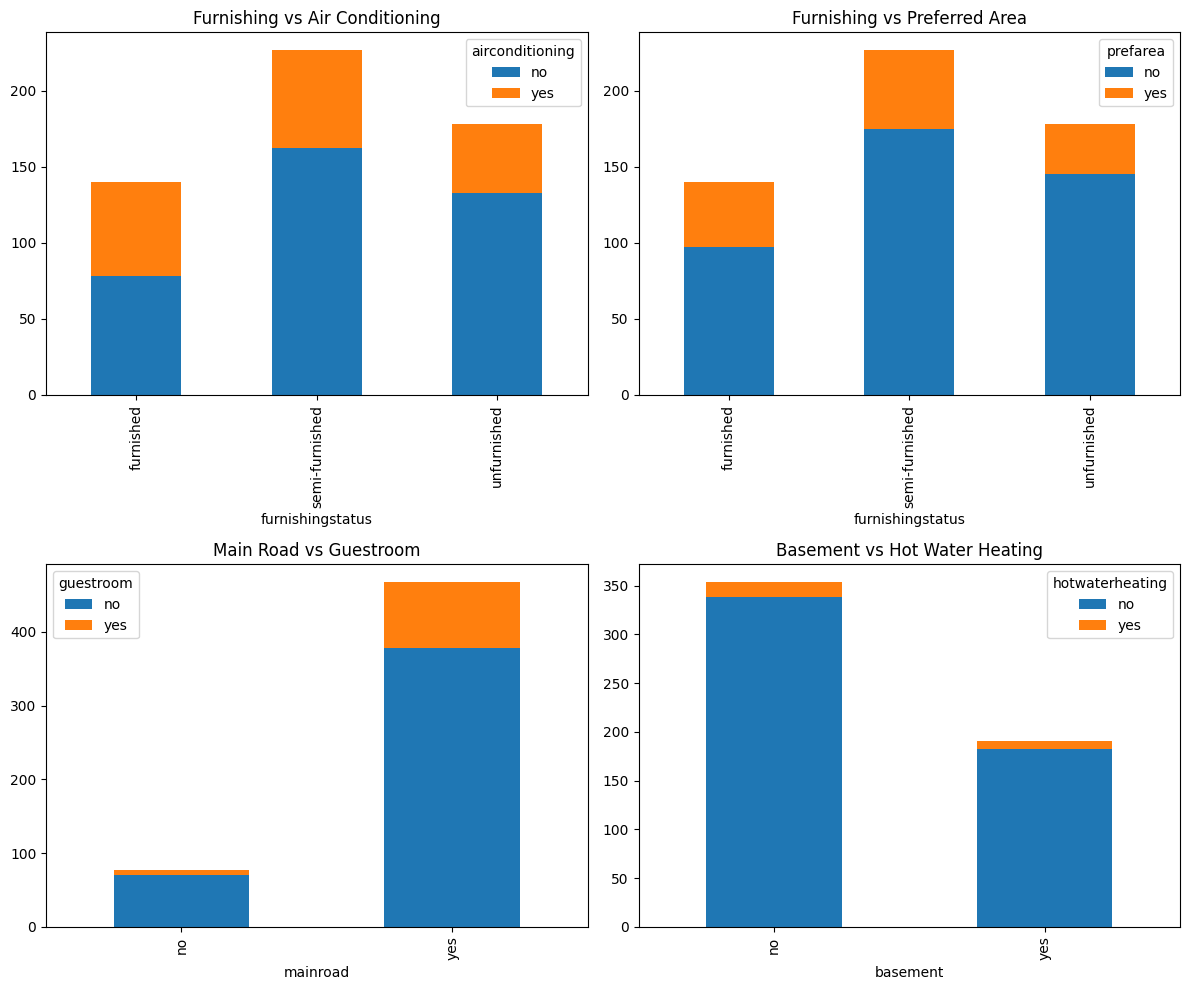

In [23]:

# Stacked bar charts for selected pairs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pd.crosstab(df['furnishingstatus'], df['airconditioning']).plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title('Furnishing vs Air Conditioning')
pd.crosstab(df['furnishingstatus'], df['prefarea']).plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('Furnishing vs Preferred Area')
pd.crosstab(df['mainroad'], df['guestroom']).plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title('Main Road vs Guestroom')
pd.crosstab(df['basement'], df['hotwaterheating']).plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Basement vs Hot Water Heating')
plt.tight_layout()
plt.show()

### Multivariate Analysis

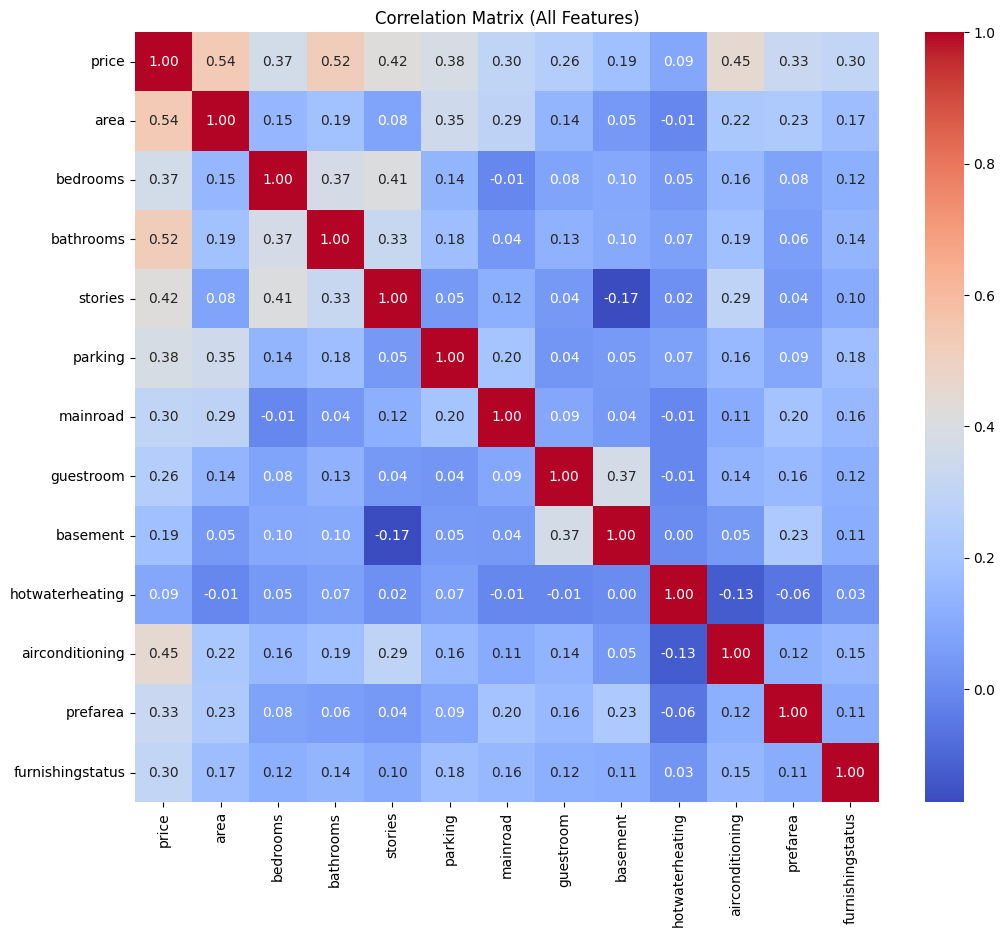

In [24]:
# Encode binary categoricals as 0/1
df_enc = df.copy()
for col in ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']:
    df_enc[col] = df_enc[col].map({'yes':1, 'no':0})
furn_map = {'unfurnished':0, 'semi-furnished':1, 'furnished':2}
df_enc['furnishingstatus'] = df_enc['furnishingstatus'].map(furn_map)

all_vars = num_cols + [c for c in cat_cols if c not in num_cols]
plt.figure(figsize=(12, 10))
sns.heatmap(df_enc[all_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (All Features)')
plt.show()

### Pairplot with Categorical Hue

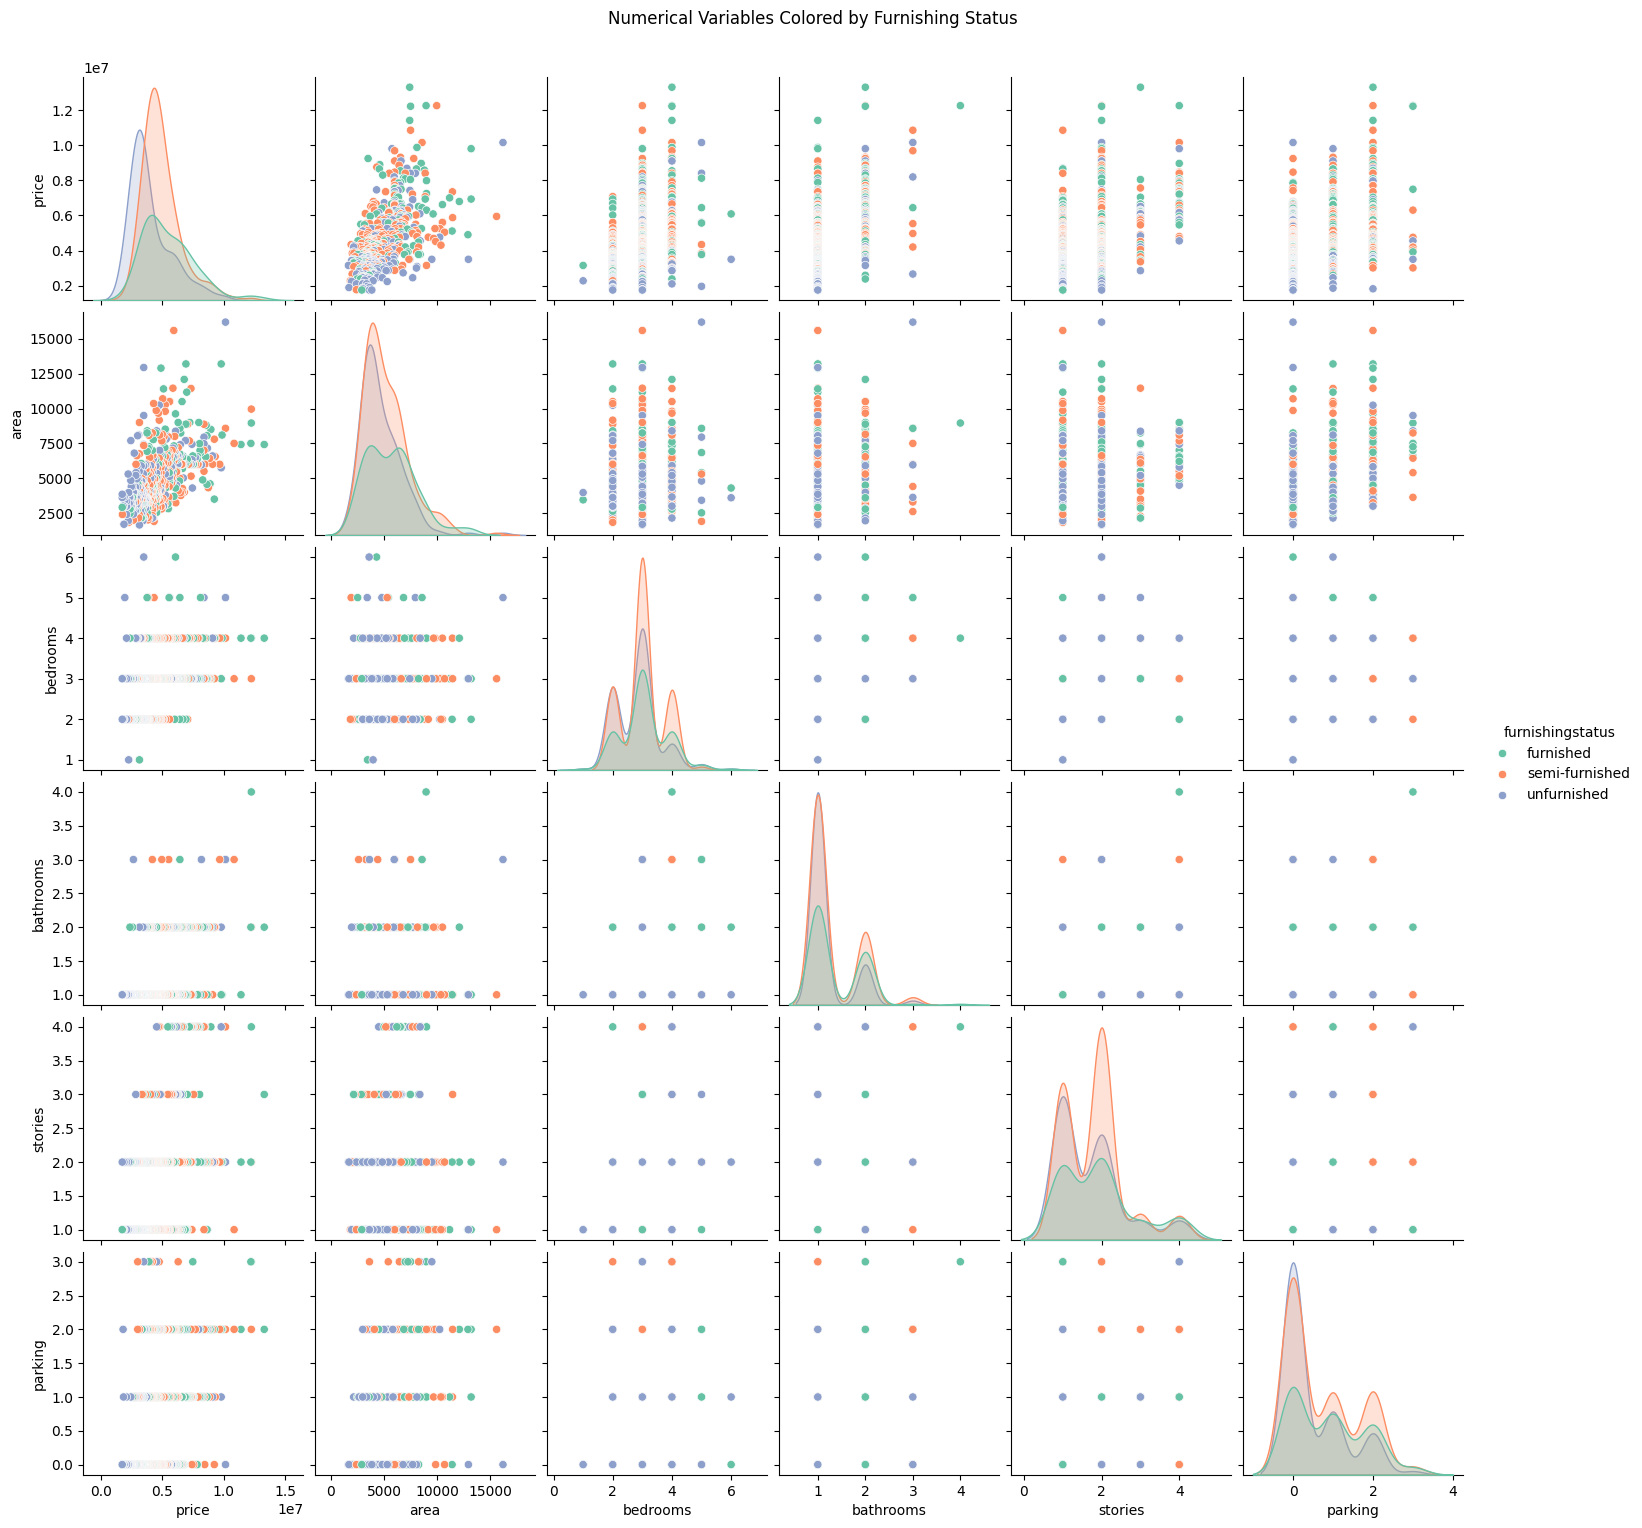

In [25]:
sns.pairplot(df[num_cols + ['furnishingstatus']], 
             hue='furnishingstatus', 
             diag_kind='kde', 
             palette='Set2')
plt.suptitle('Numerical Variables Colored by Furnishing Status', y=1.02)
plt.show()

### Dimensionality Reduction (PCA & t-SNE)

In [26]:
# Scale numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

Text(0, 0.5, 'PC2')

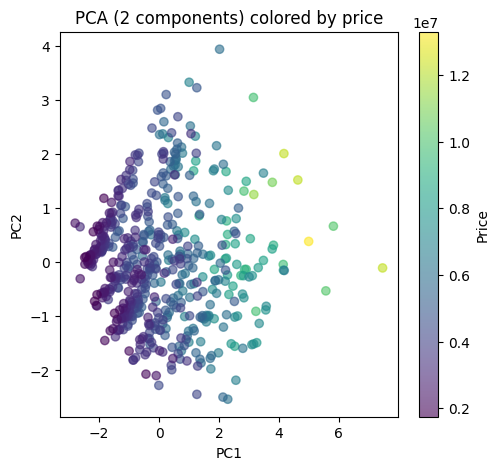

In [27]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['price'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Price')
plt.title('PCA (2 components) colored by price')
plt.xlabel('PC1')
plt.ylabel('PC2')

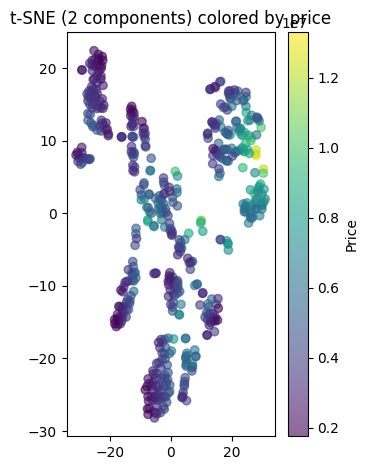

In [28]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
plt.subplot(1,2,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['price'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Price')
plt.title('t-SNE (2 components) colored by price')
plt.tight_layout()
plt.show()

### Outlier Detection and Treatment

In [29]:
# IQR method
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data < lower) | (data > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(df[col])
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")


price: 15 outliers (2.75%)
area: 12 outliers (2.20%)
bedrooms: 12 outliers (2.20%)
bathrooms: 1 outliers (0.18%)
stories: 41 outliers (7.52%)
parking: 12 outliers (2.20%)


In [30]:
# Z-score method
from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_cols]))
outlier_z = (z_scores > 3).sum(axis=0)
for col, count in zip(num_cols, outlier_z):
    print(f"{col}: {count} outliers ({count/len(df)*100:.2f}%)")

price: 6 outliers (1.10%)
area: 7 outliers (1.28%)
bedrooms: 2 outliers (0.37%)
bathrooms: 11 outliers (2.02%)
stories: 0 outliers (0.00%)
parking: 0 outliers (0.00%)


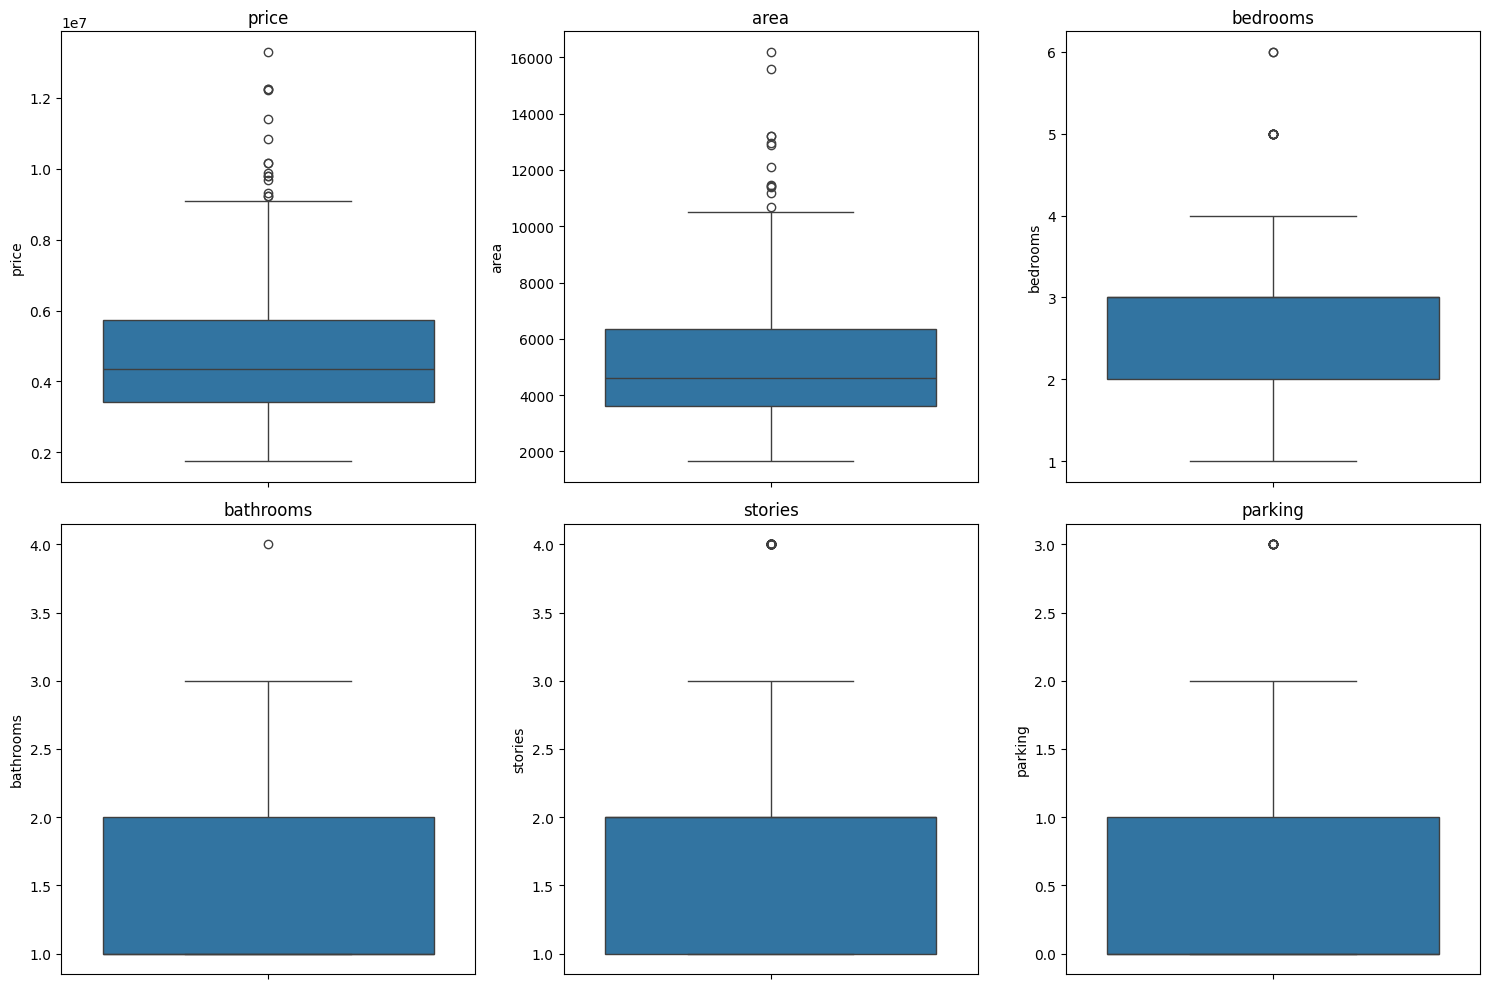

In [31]:
# Boxplots for visual inspection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()